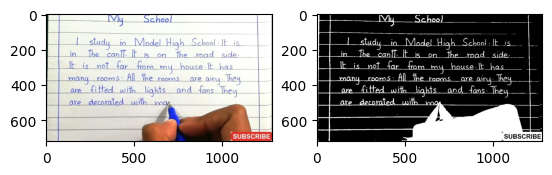

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

url = "/content/handwrittingessay.jpg"
img = cv2.imread(url)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
ret, bw = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
plt.subplot(1,2,1);plt.imshow(rgb)
plt.subplot(1,2,2);plt.imshow(bw,cmap='gray')

Text(0.5, 1.0, 'Method 1')

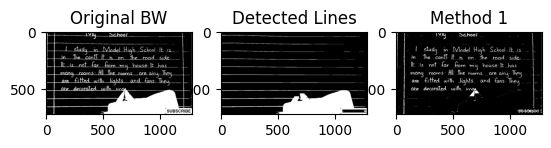

In [ ]:
#Method 1 (Threshold Binary INV)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40,1))

# Detect horizontal lines
horizontal_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel)

# Subtract lines from image
no_lines = cv2.subtract(bw, horizontal_lines)

plt.subplot(1,3,1); plt.imshow(bw, cmap='gray'); plt.title("Original BW")
plt.subplot(1,3,2); plt.imshow(horizontal_lines, cmap='gray'); plt.title("Detected Lines")
plt.subplot(1,3,3); plt.imshow(no_lines, cmap='gray'); plt.title("Method 1")

Text(0.5, 1.0, 'Method 2')

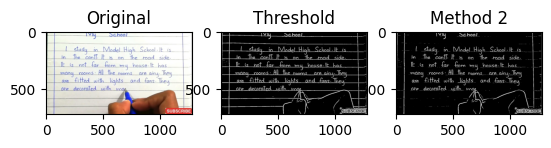

In [ ]:
#Method 2 (Adaptive Threshold)

bw = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15, 5
)


#Detect horizontal lines
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40,1))
detected_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, horizontal_kernel)

#Remove lines
method2 = cv2.subtract(bw, detected_lines)

#clean small noise
kernel = np.ones((2,2), np.uint8)
bw_clean = cv2.morphologyEx(method2, cv2.MORPH_CLOSE, kernel)

plt.subplot(1,3,1); plt.imshow(rgb); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(bw, cmap='gray'); plt.title("Threshold")
plt.subplot(1,3,3); plt.imshow(method2, cmap='gray'); plt.title("Method 2")

Text(0.5, 1.0, 'Dilated Text')

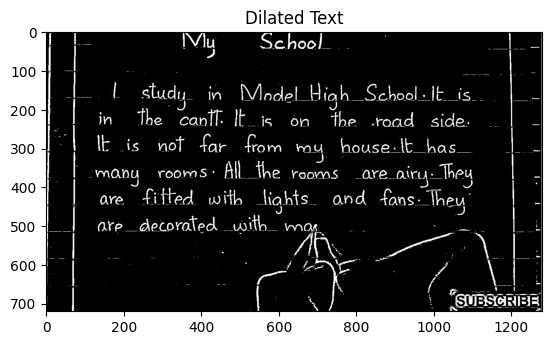

In [ ]:
#Method 3 (Dilate)

#Dilate
kernel = np.ones((2,2),np.uint8)
dil = cv2.dilate(bw,kernel,iterations=1)

#Detect horizontal lines
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40,1))
detected_lines = cv2.morphologyEx(dil, cv2.MORPH_OPEN, horizontal_kernel)

#Remove lines
method3 = cv2.subtract(bw, detected_lines)


plt.imshow(method3,cmap='gray')
plt.title("Dilated Text")

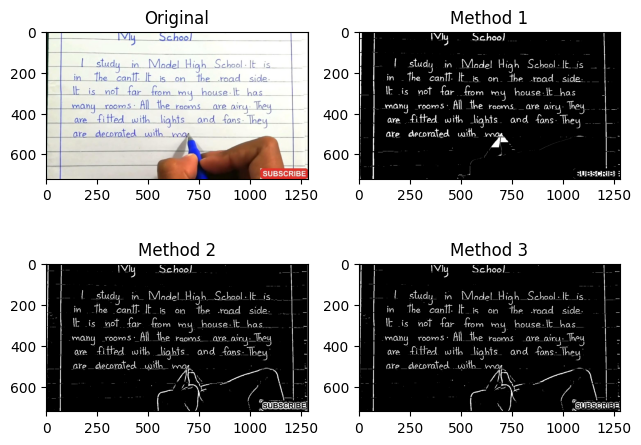

In [ ]:
# plt.figure(figsize=(14,15))

plt.subplot(2,2,1); plt.imshow(rgb); plt.title("Original")
plt.subplot(2,2,2); plt.imshow(no_lines,cmap='gray'); plt.title("Method 1")
plt.subplot(2,2,3); plt.imshow(method2,cmap='gray'); plt.title("Method 2")
plt.subplot(2,2,4); plt.imshow(method3,cmap='gray'); plt.title("Method 3")

plt.tight_layout()
plt.show()
